### Testing the loss introduced by the nodal-to-modal construction

In previous verification experiments, we established that SIAC postprocessing
reproduces polynomials of degree $k$ exactly when applied to DG solutions of
degree $p = (k-1)/2$ with the standard kernel.

However, those results assume that the DG representation is obtained via an exact $L^2$ projection of the underlying function.

Combined with the nodal-to-modal roundtrip tests, this implies that if the input data already corresponds to a nodal DG solution, then SIAC achieves the expected theoretical reproduction.

In this notebook, we consider a different and practically relevant setting:
the DG representation is constructed from sampled data, interpreted as nodal
values and converted to modal coefficients using a nodal-to-modal transform.

$$
\text{exact function}
\;\longrightarrow\;
\text{sampled nodal data}
\;\longrightarrow\;
\text{modal DG representation}.
$$

This construction generally does not coincide with the exact $L^2$ projection.

We therefore compare two pipelines:
$$
\begin{cases}
\text{$L^2$ projection} \;\rightarrow\; \text{DG} \;\rightarrow\; \text{SIAC},\\
\text{nodal sampling} \;\rightarrow\; \text{modal DG} \;\rightarrow\; \text{SIAC}.
\end{cases}
$$

The goal is to quantify the loss introduced by the nodal-to-modal approach, even in situations where SIAC is theoretically expected to reproduce the underlying function exactly.

This highlights that any deviation from exact reproduction is not caused by the SIAC procedure itself, but rather by the approximation error introduced in the nodal-to-modal construction. It also motivates the exploration of alternative approaches, such as improved projection methods.

Mathematically, we consider the following setting.

Let $P_p$ denote the $L^2$-projection onto $\mathbb{P}_p$, the space of
polynomials of degree at most $p$, and let $\Pi_p$ denote the nodal-to-modal
interpolation operator. Furthermore, let $\mathcal{S}$ denote the SIAC
postprocessing operator.

Given a function $u$, we construct two DG approximations:
\begin{align*}
    \hat u_{L^2} &= P_p(u), \\
    \hat u_{\text{nodal}} &= \Pi_p(u).
\end{align*}

In general, these two approximations do not coincide. We define the difference
$$
e_p := \Pi_p(u) - P_p(u),
$$
so that
$$
\hat u_{\text{nodal}} = P_p(u) + e_p,
$$
where $e_p \in \mathbb{P}_p$ represents the error introduced by the nodal-to-modal
construction.

Applying SIAC postprocessing, we obtain:
\begin{align*}
    \mathcal{S}(\hat u_{L^2}) &= \mathcal{S}(P_p(u)), \\
    \mathcal{S}(\hat u_{\text{nodal}}) &= \mathcal{S}(P_p(u) + e_p)
    = \mathcal{S}(P_p(u)) + \mathcal{S}(e_p).
\end{align*}

By SIAC theory, if $u \in \mathbb{P}_{2p+1}$ and the kernel satisfies the
appropriate moment conditions, then
$$
\mathcal{S}(P_p(u)) = u.
$$

However, in general,
$$
\mathcal{S}(\hat u_{\text{nodal}}) = u + \mathcal{S}(e_p),
$$
and the additional term $\mathcal{S}(e_p)$ represents the loss introduced by
the nodal-to-modal construction.

Thus, even in cases where SIAC is theoretically expected to reproduce the exact
solution, this property is generally lost when the DG representation is obtained
from sampled nodal data instead of an exact $L^2$ projection.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../..")

In [2]:
from src.testing.helpers_2d import (
    run_l2_vs_nodal_modal_experiment_2d,
    plot_l2_vs_nodal_modal_experiment_2d
)

In [3]:
# -----------------------------
# 1. Problem / domain setup
# -----------------------------
xmin, xmax = -1, 1
ymin, ymax = -1, 1
xlim = (xmin, xmax)
ylim = (ymin, ymax)

poly_deg = 5

# --------------------------------------------------
# 1. Exact polynomial test function
# --------------------------------------------------
def exact_poly2d_scaled(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    xhat = 2.0 * (x - xlim[0]) / (xlim[1] - xlim[0]) - 1.0
    yhat = 2.0 * (y - ylim[0]) / (ylim[1] - ylim[0]) - 1.0

    u = 1.0 - 0.8*xhat**2 - 0.6*yhat**2

    if poly_deg >= 3:
        u += 0.15*xhat**3 - 0.12*yhat**3 + 0.08*xhat*yhat
    if poly_deg >= 4:
        u += 0.5*xhat**4 + 0.4*yhat**4 - 0.25*xhat**2*yhat**2
    if poly_deg >= 5:
        u += -0.18*xhat**5 + 0.12*xhat**3*yhat**2
    if poly_deg >= 6:
        u += -0.1*xhat**6
    return u

# DG polynomial degree  (SIAC should reproduce p = (poly_deg - 1) / 2 exactly)
p = int(np.ceil((poly_deg-1) / 2))
order = p + 1

# DG mesh resolution
Kx, Ky = 24, 24

# SIAC parameters
moments = 2 * p
BSorder = p + 1

# --------------------------------------------------
# 2. Run experiment
# --------------------------------------------------
results = run_l2_vs_nodal_modal_experiment_2d(
    exact_func=exact_poly2d_scaled,
    poly_deg=poly_deg,
    p=p,
    moments=moments,
    Kx=Kx,
    Ky=Ky,
    xlim=xlim,
    ylim=ylim,
)

summary = results["error_summary"]
params = results["params"]

print(f"Exact Polynomial degree:    {params['poly_deg']}")
print(f"DG degree:                  p = {params['p']}")
print(f"SIAC parameters:            r = {params['moments']}, n = {params['BSorder']}")
print(f"trim = {params['trim']}")
print()

print("DG L2 max err   :", summary["dg_l2_max"])
print("DG L2 rel err   :", summary["dg_l2_rel_l2"])
print("SIAC L2 max err :", summary["siac_l2_max"])
print("SIAC L2 rel err :", summary["siac_l2_rel_l2"])
print()
print("DG NM max err   :", summary["dg_nm_max"])
print("DG NM rel err   :", summary["dg_nm_rel_l2"])
print("SIAC NM max err :", summary["siac_nm_max"])
print("SIAC NM rel err :", summary["siac_nm_rel_l2"])


Exact Polynomial degree:    5
DG degree:                  p = 2
SIAC parameters:            r = 4, n = 3
trim = 120

DG L2 max err   : 6.782581543551824e-05
DG L2 rel err   : 1.338745495795769e-05
SIAC L2 max err : 3.552713678800501e-15
SIAC L2 rel err : 9.002033915445935e-16

DG NM max err   : 0.00010037151575270631
DG NM rel err   : 1.55637376989626e-05
SIAC NM max err : 7.026996812209418e-07
SIAC NM rel err : 5.44791865611748e-07


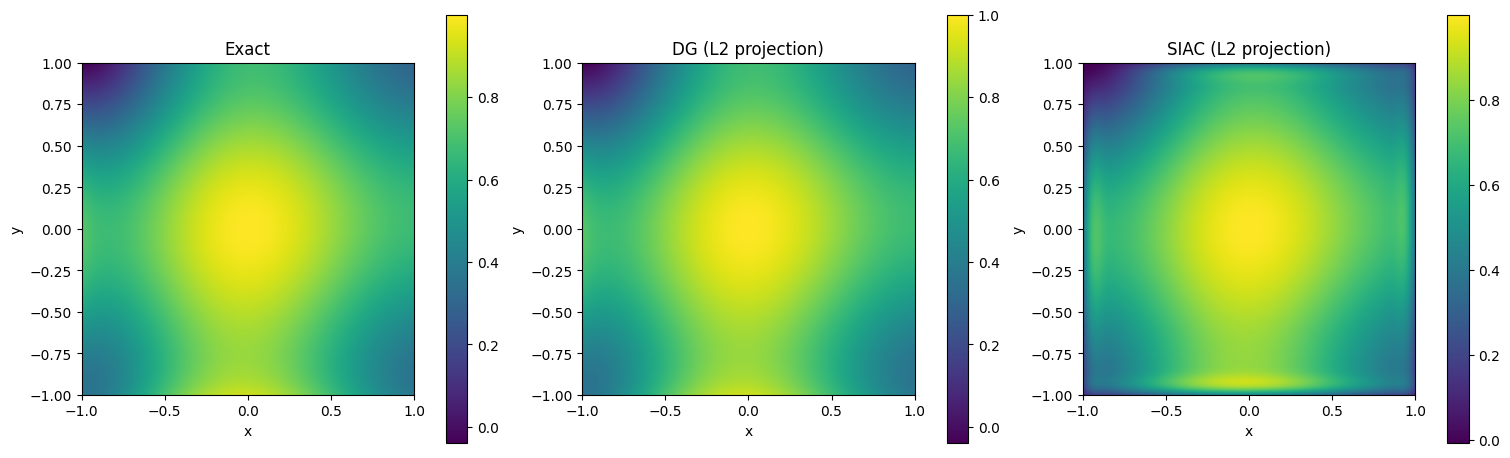

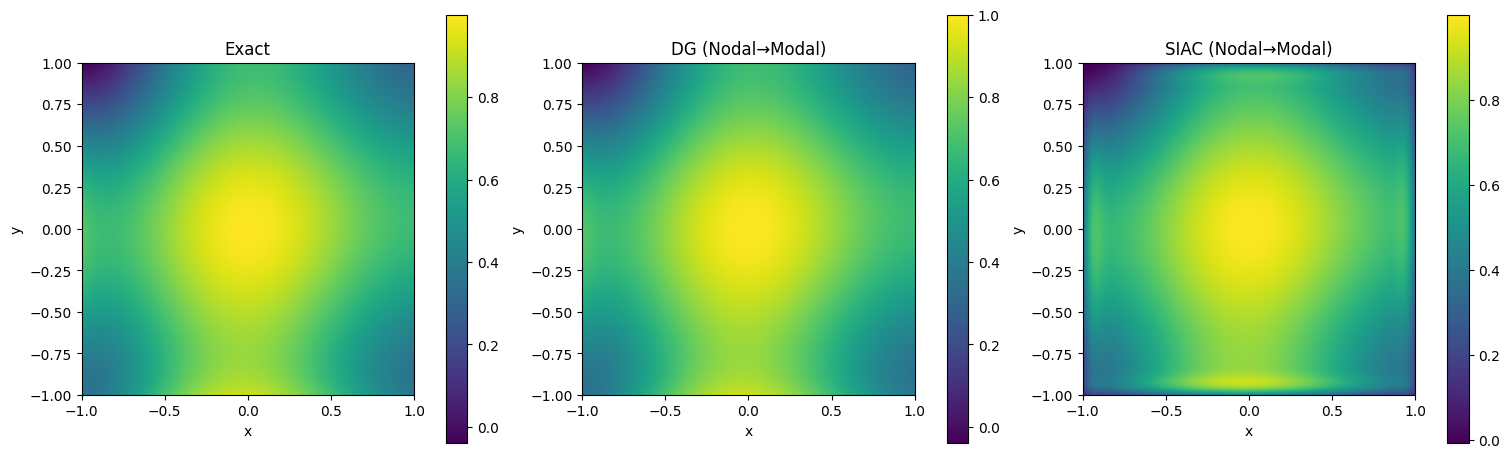

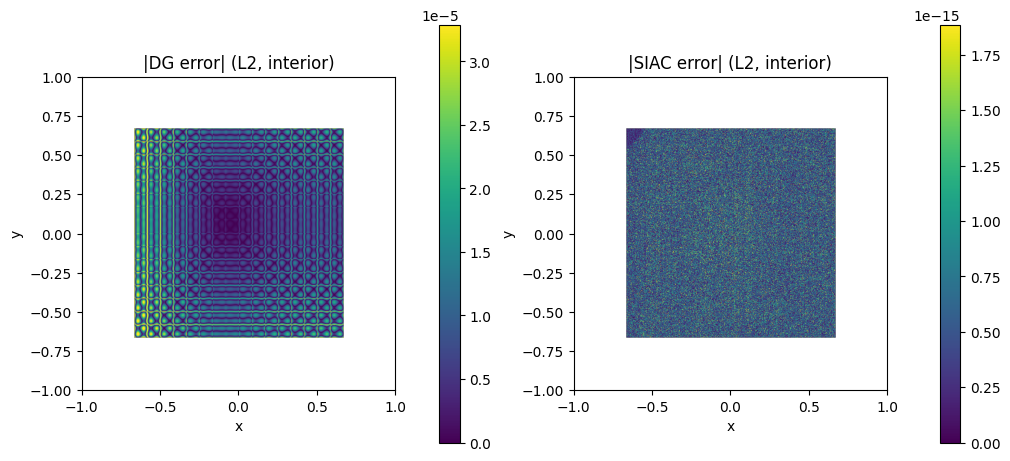

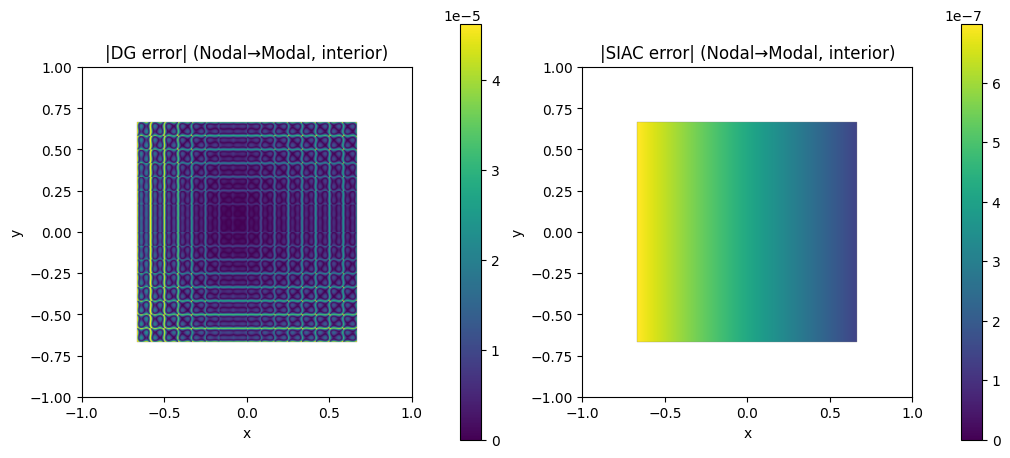

In [4]:
# --------------------------------------------------
# 3. Plot results
# --------------------------------------------------
plot_l2_vs_nodal_modal_experiment_2d(results, log_errors=False)

In [5]:
# Run the same thing, but now use even polynomial degree k
# and DG basis degree p=k-1, use standard kernel with 
# moments conserved k with associated BSorder

# -----------------------------
# 1. Problem / domain setup
# -----------------------------
xmin, xmax = -1, 1
ymin, ymax = -1, 1
xlim = (xmin, xmax)
ylim = (ymin, ymax)

poly_deg = 5

# --------------------------------------------------
# 1. Exact polynomial test function
# --------------------------------------------------
def exact_poly2d_scaled(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    xhat = 2.0 * (x - xlim[0]) / (xlim[1] - xlim[0]) - 1.0
    yhat = 2.0 * (y - ylim[0]) / (ylim[1] - ylim[0]) - 1.0

    u = 1.0 - 0.8*xhat**2 - 0.6*yhat**2

    if poly_deg >= 3:
        u += 0.15*xhat**3 - 0.12*yhat**3 + 0.08*xhat*yhat
    if poly_deg >= 4:
        u += 0.5*xhat**4 + 0.4*yhat**4 - 0.25*xhat**2*yhat**2
    if poly_deg >= 5:
        u += -0.18*xhat**5 + 0.12*xhat**3*yhat**2
    if poly_deg >= 6:
        u += -0.1*xhat**6
    return u

# p = poly_deg - 1
p = int(poly_deg - 1)
order = p + 1

# DG mesh resolution
Kx, Ky = 24, 24

# SIAC parameters
moments = poly_deg-1          # corresponds to conserving poly_deg moments
BSorder = int(moments / 2) + 1

# --------------------------------------------------
# 2. Run experiment
# --------------------------------------------------
results = run_l2_vs_nodal_modal_experiment_2d(
    exact_func=exact_poly2d_scaled,
    poly_deg=poly_deg,
    p=p,
    Kx=Kx,
    Ky=Ky,
    xlim=xlim,
    ylim=ylim, 
    moments=moments, 
    BSorder=BSorder
)

summary = results["error_summary"]
params = results["params"]

print(f"Exact Polynomial degree:    {params['poly_deg']}")
print(f"DG degree:                  p = {params['p']}")
print(f"SIAC parameters:            r = {params['moments']}, n = {params['BSorder']}")
print(f"trim = {params['trim']}")
print()

print("DG L2 max err   :", summary["dg_l2_max"])
print("DG L2 rel err   :", summary["dg_l2_rel_l2"])
print("SIAC L2 max err :", summary["siac_l2_max"])
print("SIAC L2 rel err :", summary["siac_l2_rel_l2"])
print()
print("DG NM max err   :", summary["dg_nm_max"])
print("DG NM rel err   :", summary["dg_nm_rel_l2"])
print("SIAC NM max err :", summary["siac_nm_max"])
print("SIAC NM rel err :", summary["siac_nm_rel_l2"])


Exact Polynomial degree:    5
DG degree:                  p = 4
SIAC parameters:            r = 4, n = 3
trim = 200

DG L2 max err   : 2.0680850365550896e-09
DG L2 rel err   : 1.031491092668145e-09
SIAC L2 max err : 4.440892098500626e-15
SIAC L2 rel err : 1.2559867637945343e-15

DG NM max err   : 5.681231152188104e-09
DG NM rel err   : 1.8141368307543013e-09
SIAC NM max err : 4.107825191113079e-15
SIAC NM rel err : 1.075094118810435e-15


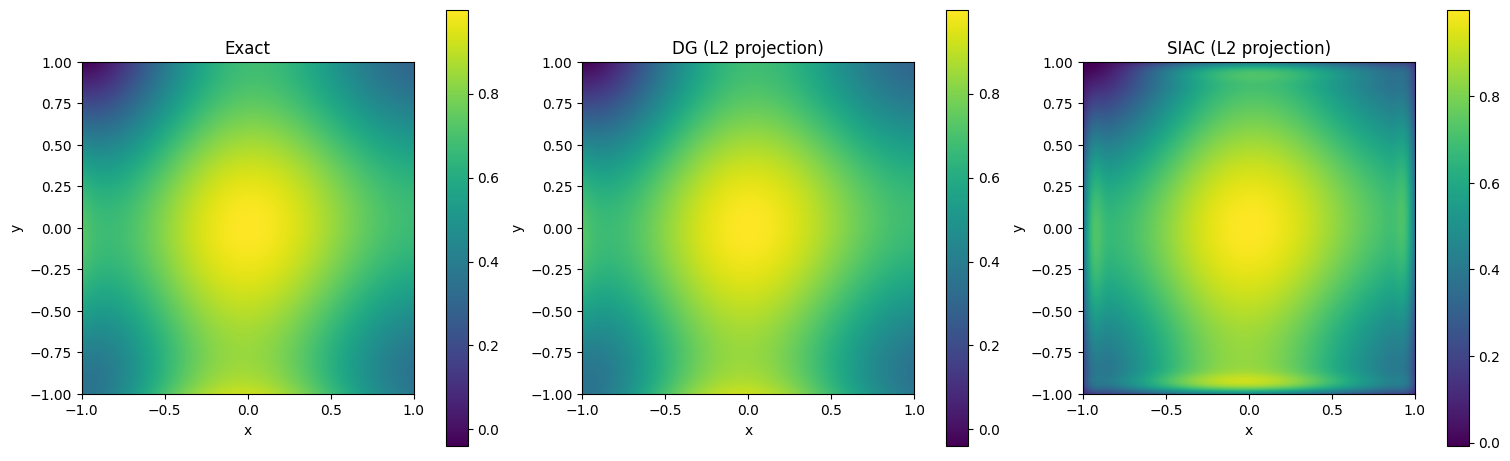

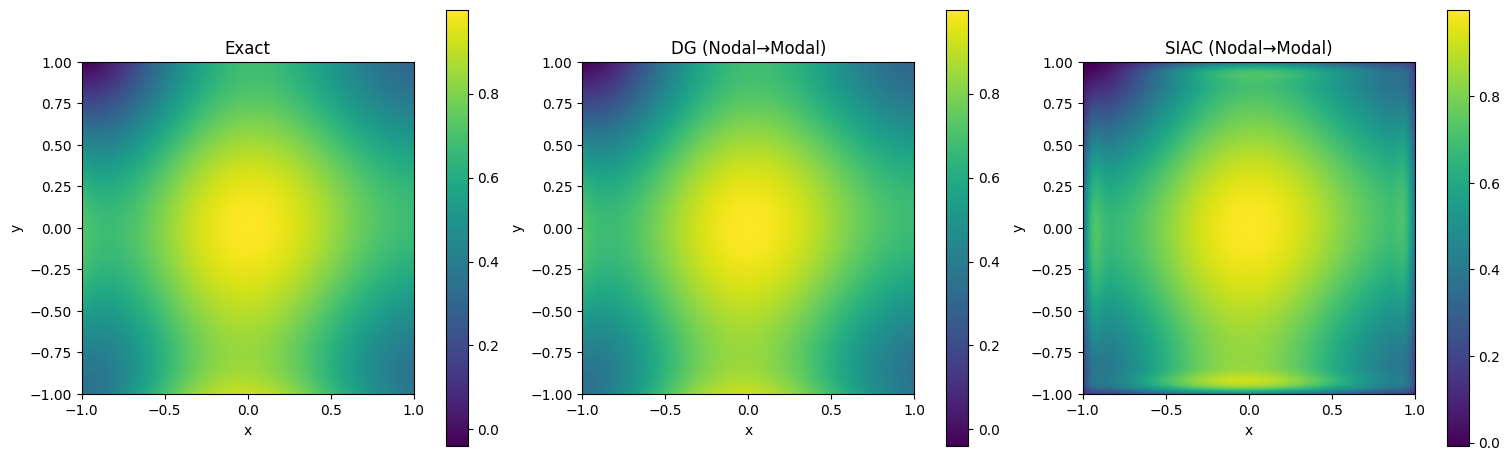

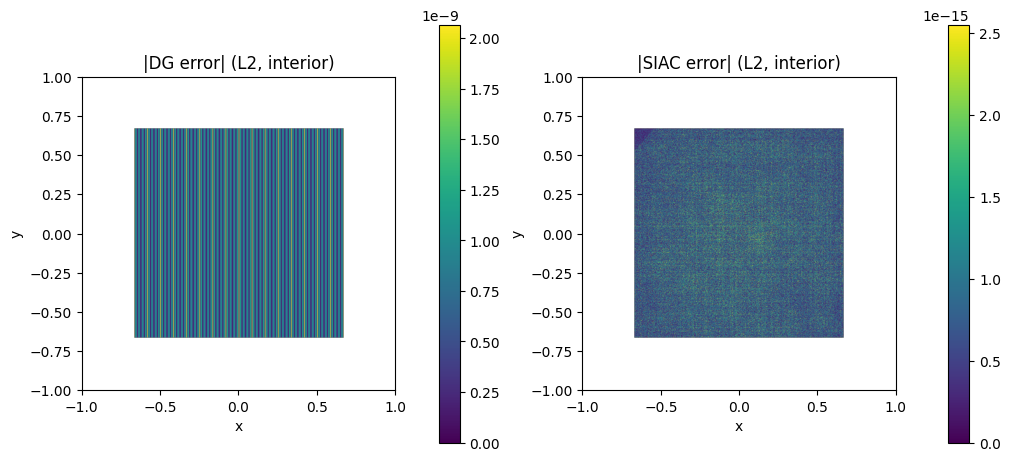

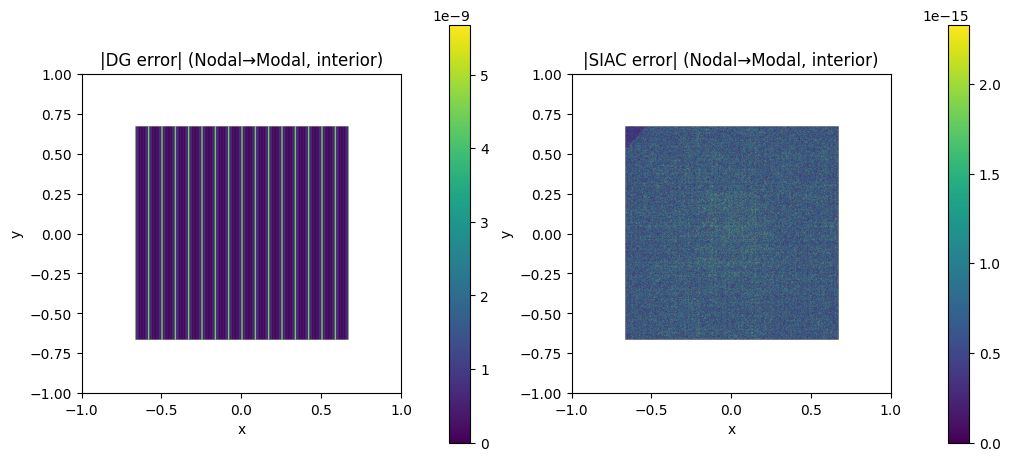

In [6]:
# --------------------------------------------------
# 3. Plot results
# --------------------------------------------------
plot_l2_vs_nodal_modal_experiment_2d(results, log_errors=False)

In [7]:
# Now lastly, we run the test on a smooth function, but not a polynomial

# -----------------------------
# 1. Problem / domain setup
# -----------------------------
xmin, xmax = -1, 1
ymin, ymax = -1, 1
xlim = (xmin, xmax)
ylim = (ymin, ymax)

# --------------------------------------------------
# 1. Exact sine test function
# --------------------------------------------------

def exact_sine_scaled(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    # xhat = 2.0 * (x - xlim[0]) / (xlim[1] - xlim[0]) - 1.0
    # yhat = 2.0 * (y - ylim[0]) / (ylim[1] - ylim[0]) - 1.0
    u = np.sin(0.5*np.pi*x*y)
    return u
def exact_sine_cos(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    xhat = 2.0 * (x - xlim[0]) / (xlim[1] - xlim[0]) - 1.0
    yhat = 2.0 * (y - ylim[0]) / (ylim[1] - ylim[0]) - 1.0
    
    u = 0.5*np.sin(np.pi*xhat) * np.cos(np.pi*yhat) + 0.5*np.sin(2*np.pi*xhat*yhat)
    return u


p = 2
order = p + 1

# DG mesh resolution
Kx, Ky = 24, 24

# SIAC parameters
moments = 2*p
BSorder = p + 1

# --------------------------------------------------
# 2. Run experiment
# --------------------------------------------------
results = run_l2_vs_nodal_modal_experiment_2d(
    exact_func=exact_sine_cos,
    p=p,
    Kx=Kx,
    Ky=Ky,
    xlim=xlim,
    ylim=ylim, 
    moments=moments, 
    BSorder=BSorder
)

summary = results["error_summary"]
params = results["params"]

print(f"DG degree:                  p = {params['p']}")
print(f"SIAC parameters:            r = {params['moments']}, n = {params['BSorder']}")
print(f"trim = {params['trim']}")
print()

print("DG L2 max err   :", summary["dg_l2_max"])
print("DG L2 rel err   :", summary["dg_l2_rel_l2"])
print("SIAC L2 max err :", summary["siac_l2_max"])
print("SIAC L2 rel err :", summary["siac_l2_rel_l2"])
print()
print("DG NM max err   :", summary["dg_nm_max"])
print("DG NM rel err   :", summary["dg_nm_rel_l2"])
print("SIAC NM max err :", summary["siac_nm_max"])
print("SIAC NM rel err :", summary["siac_nm_rel_l2"])


DG degree:                  p = 2
SIAC parameters:            r = 4, n = 3
trim = 120

DG L2 max err   : 0.00028454993248692995
DG L2 rel err   : 7.830643543153659e-05
SIAC L2 max err : 3.580836924088615e-06
SIAC L2 rel err : 2.909434788584042e-06

DG NM max err   : 0.0004201930750816138
DG NM rel err   : 9.114886108082906e-05
SIAC NM max err : 1.034986350956224e-06
SIAC NM rel err : 1.3740045486070218e-06


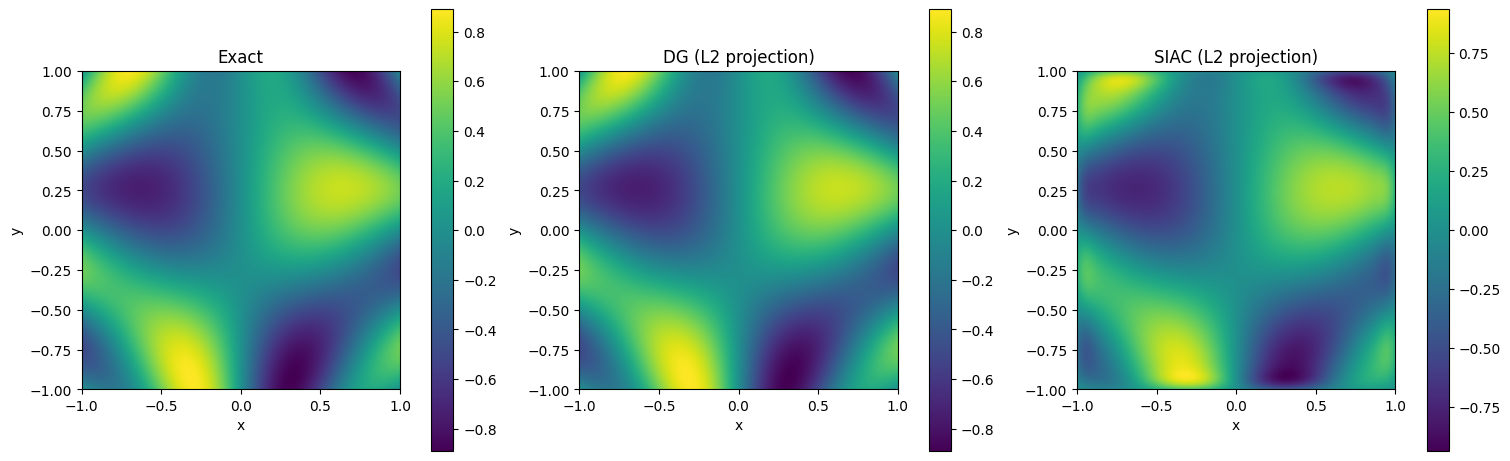

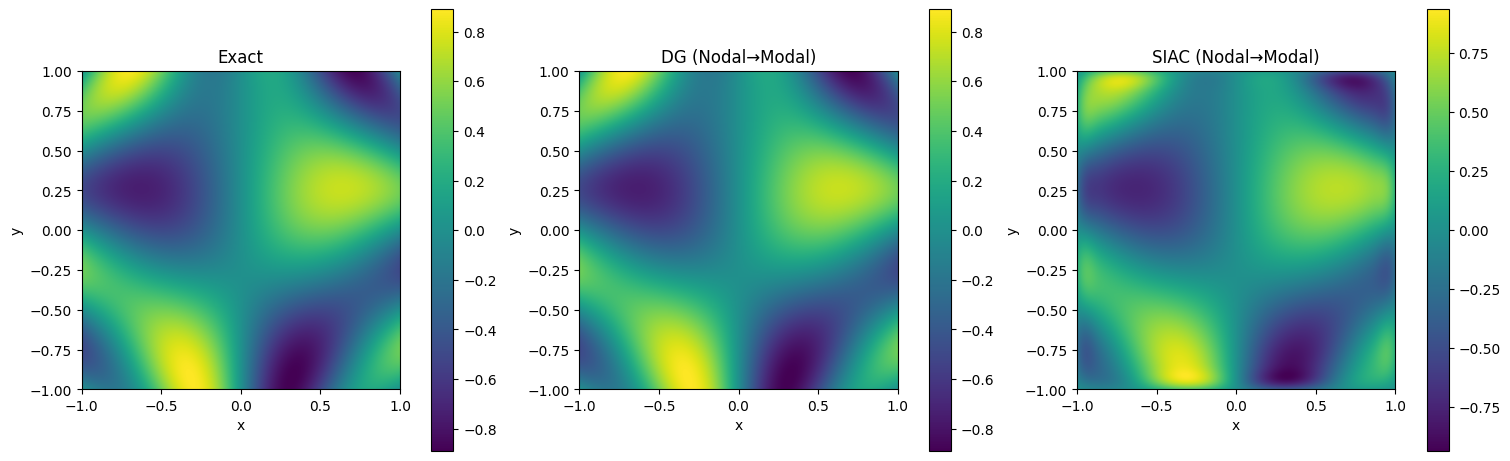

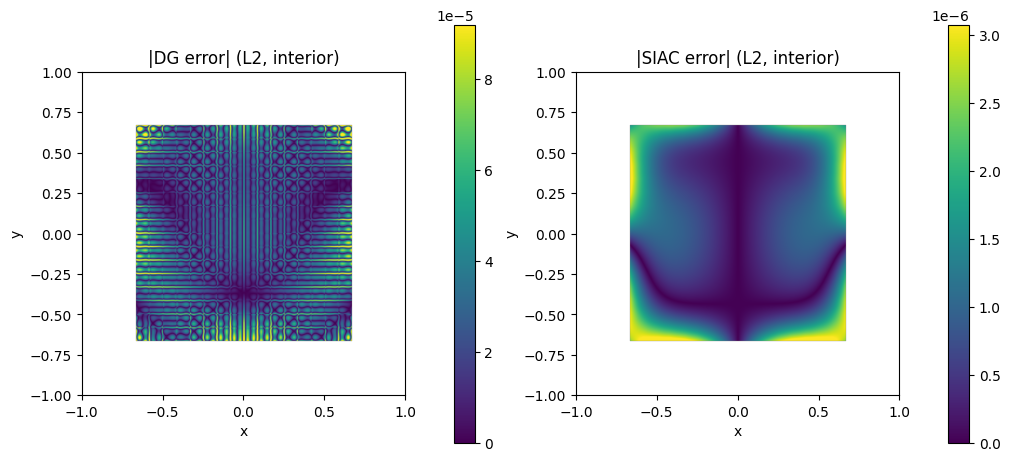

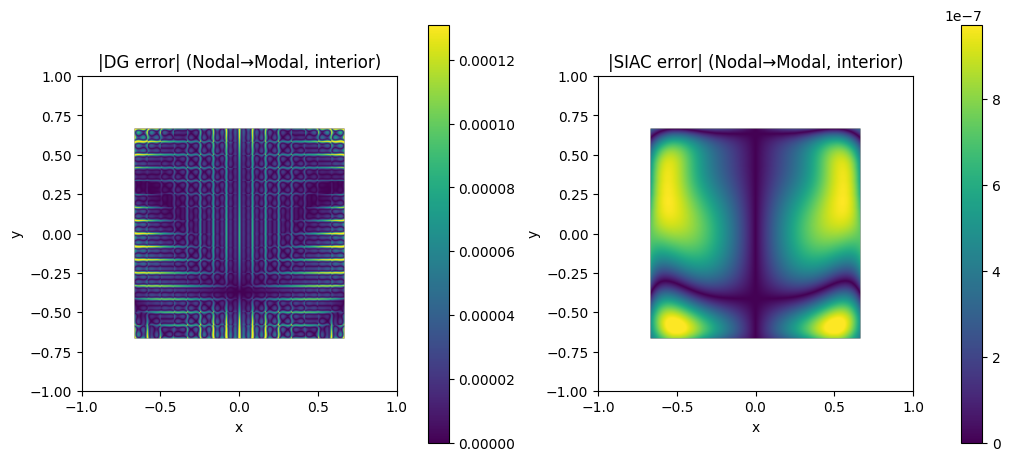

In [8]:
# --------------------------------------------------
# 3. Plot results
# --------------------------------------------------
plot_l2_vs_nodal_modal_experiment_2d(results, log_errors=False)